# 🔥 Fire Chemical Flame Detection — Kaggle Experiment Hub
**6-class flame classification | Custom EfficientNet-style CNN | No pretrained weights**

Classes: `0_background` | `1_sodium` | `2_copper` | `3_strontium` | `4_potassium` | `5_normal_fire`

---
> **HOW TO USE THIS NOTEBOOK**
> 1. Run Cell 1 once (imports/GPU check)
> 2. Edit **Cell 2 toggles only** between experiments
> 3. Run all cells top-to-bottom — outputs auto-saved to unique folder
> 4. Run **Cell 13** anytime to compare all past runs
> 5. Never edit below Cell 2 unless you know what you're doing

In [24]:
# ============================================================
# CELL 1 — IMPORTS & GPU CHECK
# ============================================================
import os, sys, json, time, math, copy, glob, shutil, random, warnings
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from pathlib import Path
from PIL import Image, UnidentifiedImageError
from collections import defaultdict
from datetime import datetime

import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader, Subset
import torchvision.transforms as transforms
import torchvision.transforms.functional as TF
from torchvision.datasets import ImageFolder

from sklearn.model_selection import StratifiedShuffleSplit
from sklearn.metrics import classification_report, confusion_matrix

warnings.filterwarnings('ignore')

# ── GPU Check ──────────────────────────────────────────────
DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'Device      : {DEVICE}')
if torch.cuda.is_available():
    print(f'GPU         : {torch.cuda.get_device_name(0)}')
    print(f'VRAM        : {torch.cuda.get_device_properties(0).total_memory / 1e9:.2f} GB')
else:
    print('WARNING: No GPU — training will be slow!')

print(f'Python      : {sys.version.split()[0]}')
print(f'PyTorch     : {torch.__version__}')
print('Cell 1 complete')

Device      : cuda
GPU         : Tesla T4
VRAM        : 15.64 GB
Python      : 3.12.12
PyTorch     : 2.10.0+cu128
Cell 1 complete


In [25]:
# ============================================================
# CELL 2 — CONFIGURATION (edit only this cell between runs)
# ============================================================

# ── Paths ──────────────────────────────────────────────────
DATA_ROOT      = '/kaggle/input/private-dataset/train/train'
BASE_OUT       = '/kaggle/working'

# ── Hyperparameters ────────────────────────────────────────
IMG_SIZE       = 128
BATCH_SIZE     = 32
NUM_EPOCHS     = 40
LEARNING_RATE  = 1e-3
WEIGHT_DECAY   = 1e-4
DROPOUT_RATE   = 0.3
LABEL_SMOOTHING= 0.05
SEED           = 42
EARLY_STOP_PAT = 15
CONF_THRESHOLD = 0.70    # below this = uncertain prediction

# ── Architecture ───────────────────────────────────────────
# B: Medium ~2.1M params — recommended
ARCH_VARIANT   = 'B'

# ── Loss ───────────────────────────────────────────────────
LOSS_TYPE      = 'focal'      # 'crossentropy' | 'focal'
FOCAL_GAMMA    = 1.0          # 1.0 = gentle, 2.0 = aggressive

# ── Optimizer & Scheduler ──────────────────────────────────
OPT_TYPE       = 'adamw'      # 'adam' | 'adamw'
SCHED_TYPE     = 'cosine'     # 'plateau' | 'cosine'
COSINE_T0      = 10

# ── Augmentation ───────────────────────────────────────────
USE_MIXUP      = False
MIXUP_ALPHA    = 0.4

# ── Classes ────────────────────────────────────────────────
CLASS_NAMES    = ['0_background','1_sodium','2_copper',
                  '3_strontium','4_potassium','5_normal']
NUM_CLASSES    = len(CLASS_NAMES)

TRAIN_RATIO    = 0.70
VAL_RATIO      = 0.15

# ── Auto-increment run folder ──────────────────────────────
existing = sorted(glob.glob(os.path.join(BASE_OUT, 'outputs_run_*')))
run_id   = len(existing) + 1
RUN_DIR  = os.path.join(BASE_OUT, f'outputs_run_{run_id:03d}')
os.makedirs(RUN_DIR, exist_ok=True)

# ── Seed everything ────────────────────────────────────────
def seed_everything(seed):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark     = False

seed_everything(SEED)

print(f'Run ID      : {run_id}')
print(f'Run folder  : {RUN_DIR}')
print(f'Data root   : {DATA_ROOT}')
print(f'Classes     : {CLASS_NAMES}')
print(f'Device      : {DEVICE}')
print('Cell 2 complete')

Run ID      : 4
Run folder  : /kaggle/working/outputs_run_004
Data root   : /kaggle/input/private-dataset/train/train
Classes     : ['0_background', '1_sodium', '2_copper', '3_strontium', '4_potassium', '5_normal']
Device      : cuda
Cell 2 complete


## 🔧 MODIFICATION GUIDE — Read Before Changing Anything

> Only ever edit **Cell 2**. All other cells adapt automatically.

| Problem | Cell 2 Settings |
|---|---|
| **Fix Scale/Brightness Bias** | `IMG_SIZE=128`, `USE_MIXUP=True`, `ARCH_VARIANT='A'`, `SEED=42` |
| **Fix Strontium/Potassium confusion** | `ARCH_VARIANT='C'` or `'D'`, `LABEL_SMOOTHING=0.15`, `USE_CUTMIX=True`, `SEED=42` |
| **Reduce overfitting** | `DROPOUT_RATE=0.5`, `LEARNING_RATE=3e-4`, `OPT_TYPE='adamw'`, `WEIGHT_DECAY=1e-3` |
| **Train faster (debug)** | `NUM_EPOCHS=15`, `BATCH_SIZE=64`, `EARLY_STOP_PAT=8` |
| **Compare architectures** | Keep all config identical, change only `ARCH_VARIANT` per run |
| **Switch to Focal Loss** | `LOSS_TYPE='focal'`, `LABEL_SMOOTHING=0.05`, `FOCAL_GAMMA=2.0` |
| **Aggressive spectral aug** | `USE_MIXUP=True`, `USE_CUTMIX=True`, `MIXUP_ALPHA=0.6` |
| **Maximum regularisation** | `DROPOUT_RATE=0.5`, `LABEL_SMOOTHING=0.15`, `USE_MIXUP=True`, `USE_CUTMIX=True` |

### Why each variant exists:
- **A** — Fewer params, very strong SE attention (reduction=8). Forces colour over spatial. Best starting point for scale bias.
- **B** — Balanced. Good baseline. SE reduction=4 gives moderate channel attention.
- **C** — Deep net with stronger stem. Maximum feature extraction. Best for spectral separation of strontium/potassium.
- **D** — Clean classifier head (no 1×1 conv). Reduces overfitting, SE reduction=8 like A but with medium depth.

### Spectral tips:
- MixUp forces the model to learn **soft colour distributions** rather than hard spatial edges
- CutMix teaches spatial robustness while preserving label structure  
- Increasing SE reduction (smaller number = stronger attention) makes the model rely more on **channel (colour) statistics**
- Avoid `RandomGrayscale` or heavy `ColorJitter` — it destroys the spectral signal you need

In [26]:
# ============================================================
# CELL 3 — SAFETY CHECKS & DATASET VALIDATION
# ============================================================
print('=' * 60)
print('PRE-TRAINING SAFETY CHECKS')
print('=' * 60)

# Check dataset path exists
if not os.path.exists(DATA_ROOT):
    raise FileNotFoundError(f'Dataset not found: {DATA_ROOT}')

# Find class folders
class_folders = sorted([
    f for f in os.listdir(DATA_ROOT)
    if os.path.isdir(os.path.join(DATA_ROOT, f))
])

if len(class_folders) == 0:
    raise ValueError('No class folders found in dataset path!')

print(f'Folders found: {class_folders}')

# Verify class names match
for cls in CLASS_NAMES:
    if cls not in class_folders:
        print(f'WARNING: {cls} not found in dataset!')

# Count images and scan for corrupted files
class_counts = {}
corrupted_total = 0

print(f'\nClass Distribution:')
print('-' * 50)
for cls in class_folders:
    cls_path = os.path.join(DATA_ROOT, cls)
    all_files = [
        f for f in os.listdir(cls_path)
        if f.lower().endswith(('.jpg','.jpeg','.png','.webp'))
    ]
    corrupted = []
    for fname in all_files:
        fpath = os.path.join(cls_path, fname)
        try:
            with Image.open(fpath) as img:
                img.verify()
        except Exception:
            corrupted.append(fpath)
    for fpath in corrupted:
        os.remove(fpath)
        corrupted_total += 1
    valid = len(all_files) - len(corrupted)
    class_counts[cls] = valid
    bar = 'X' * (valid // 10)
    status = 'OK' if valid >= 80 else 'LOW'
    print(f'  [{status}] {cls:20} {valid:4} images  {bar}')

print(f'\nCorrupted images removed : {corrupted_total}')
print(f'Total valid images       : {sum(class_counts.values())}')

# Check imbalance
max_c = max(class_counts.values())
min_c = min(class_counts.values())
ratio = max_c / min_c if min_c > 0 else float('inf')
print(f'Imbalance ratio          : {ratio:.1f}:1')

USE_WEIGHTED_LOSS = ratio > 3
if USE_WEIGHTED_LOSS:
    print('Weighted loss will be applied (imbalance > 3:1)')
else:
    print('Dataset balanced — no weighted loss needed')

print('\nSAFETY CHECKS PASSED')
print('=' * 60)

PRE-TRAINING SAFETY CHECKS
Folders found: ['0_background', '1_sodium', '2_copper', '3_strontium', '4_potassium', '5_normal']

Class Distribution:
--------------------------------------------------
  [OK] 0_background          200 images  XXXXXXXXXXXXXXXXXXXX
  [OK] 1_sodium              200 images  XXXXXXXXXXXXXXXXXXXX
  [OK] 2_copper              191 images  XXXXXXXXXXXXXXXXXXX
  [OK] 3_strontium           199 images  XXXXXXXXXXXXXXXXXXX
  [OK] 4_potassium           167 images  XXXXXXXXXXXXXXXX
  [OK] 5_normal              200 images  XXXXXXXXXXXXXXXXXXXX

Corrupted images removed : 0
Total valid images       : 1157
Imbalance ratio          : 1.2:1
Dataset balanced — no weighted loss needed

SAFETY CHECKS PASSED


In [28]:
# ============================================================
# CELL 4 — TRANSFORMS & DATASET LOADING
# ============================================================

# Training transform — heavy augmentation
train_transform = transforms.Compose([
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.RandomHorizontalFlip(p=0.5),
    transforms.RandomVerticalFlip(p=0.2),
    transforms.RandomRotation(degrees=30),
    transforms.ColorJitter(
        brightness=0.5, contrast=0.4,
        saturation=0.4, hue=0.1
    ),
    transforms.RandomResizedCrop(
        IMG_SIZE, scale=(0.6, 1.0), ratio=(0.8, 1.2)
    ),
    transforms.RandomPerspective(distortion_scale=0.3, p=0.3),
    transforms.RandomGrayscale(p=0.05),
    transforms.ToTensor(),
    transforms.Normalize(
        mean=[0.485, 0.456, 0.406],
        std=[0.229, 0.224, 0.225]
    ),
    transforms.RandomErasing(p=0.1, scale=(0.02, 0.1)),
])

# Val/Test transform — no augmentation
val_transform = transforms.Compose([
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.ToTensor(),
    transforms.Normalize(
        mean=[0.485, 0.456, 0.406],
        std=[0.229, 0.224, 0.225]
    ),
])

# Load dataset
full_dataset  = ImageFolder(root=DATA_ROOT)
CLASS_NAMES   = full_dataset.classes
NUM_CLASSES   = len(CLASS_NAMES)
labels_array  = np.array(full_dataset.targets)

print(f'Dataset loaded')
print(f'Classes      : {CLASS_NAMES}')
print(f'Total images : {len(full_dataset)}')
print(f'Num classes  : {NUM_CLASSES}')

# Stratified split — BEFORE augmentation to prevent leakage
sss1 = StratifiedShuffleSplit(
    n_splits=1, test_size=(1 - TRAIN_RATIO - VAL_RATIO),
    random_state=SEED
)
trainval_idx, test_idx = next(
    sss1.split(np.zeros(len(labels_array)), labels_array)
)

val_ratio_adjusted = VAL_RATIO / (TRAIN_RATIO + VAL_RATIO)
sss2 = StratifiedShuffleSplit(
    n_splits=1, test_size=val_ratio_adjusted,
    random_state=SEED
)
tv_labels = labels_array[trainval_idx]
train_sub, val_sub = next(
    sss2.split(np.zeros(len(tv_labels)), tv_labels)
)
train_idx = trainval_idx[train_sub]
val_idx   = trainval_idx[val_sub]

print(f'\nSplit sizes:')
print(f'  Train : {len(train_idx)} ({len(train_idx)/len(full_dataset)*100:.0f}%)')
print(f'  Val   : {len(val_idx)}  ({len(val_idx)/len(full_dataset)*100:.0f}%)')
print(f'  Test  : {len(test_idx)}  ({len(test_idx)/len(full_dataset)*100:.0f}%)')

# Build subsets with correct transforms
train_ds = ImageFolder(root=DATA_ROOT, transform=train_transform)
val_ds   = ImageFolder(root=DATA_ROOT, transform=val_transform)
test_ds  = ImageFolder(root=DATA_ROOT, transform=val_transform)

train_subset = Subset(train_ds, train_idx)
val_subset   = Subset(val_ds,   val_idx)
test_subset  = Subset(test_ds,  test_idx)

train_loader = DataLoader(
    train_subset, batch_size=BATCH_SIZE,
    shuffle=True,  num_workers=2, pin_memory=True
)
val_loader = DataLoader(
    val_subset, batch_size=BATCH_SIZE,
    shuffle=False, num_workers=2, pin_memory=True
)
test_loader = DataLoader(
    test_subset, batch_size=BATCH_SIZE,
    shuffle=False, num_workers=2, pin_memory=True
)

# Save class info
class_info = {'class_names': CLASS_NAMES, 'num_classes': NUM_CLASSES}
with open(os.path.join(RUN_DIR, 'class_info.json'), 'w') as f:
    json.dump(class_info, f)

print('\nDataLoaders created')
print('Class info saved')

Dataset loaded
Classes      : ['0_background', '1_sodium', '2_copper', '3_strontium', '4_potassium', '5_normal']
Total images : 1157
Num classes  : 6

Split sizes:
  Train : 809 (70%)
  Val   : 174  (15%)
  Test  : 174  (15%)

DataLoaders created
Class info saved


In [29]:
# ============================================================
# CELL 5 — MODEL ARCHITECTURE
# Custom CNN built from EfficientNetB0 components — no pretrained weights
# ============================================================

class SEBlock(nn.Module):
    """Squeeze-and-Excitation: learns which colour channels matter most.
    Critical for flame colour identification."""
    def __init__(self, channels, reduction=4):
        super().__init__()
        reduced = max(1, channels // reduction)
        self.squeeze = nn.AdaptiveAvgPool2d(1)
        self.excite  = nn.Sequential(
            nn.Flatten(),
            nn.Linear(channels, reduced),
            nn.SiLU(),
            nn.Linear(reduced, channels),
            nn.Sigmoid()
        )
    def forward(self, x):
        s = self.squeeze(x)
        s = self.excite(s).view(x.size(0), -1, 1, 1)
        return x * s


class MBConvBlock(nn.Module):
    """Mobile Inverted Bottleneck — core EfficientNet building block."""
    def __init__(self, in_ch, out_ch, expand_ratio=6,
                 stride=1, se_reduction=4):
        super().__init__()
        self.use_skip = (stride == 1 and in_ch == out_ch)
        mid_ch = in_ch * expand_ratio
        layers = []
        if expand_ratio != 1:
            layers += [
                nn.Conv2d(in_ch, mid_ch, 1, bias=False),
                nn.BatchNorm2d(mid_ch),
                nn.SiLU(inplace=True)
            ]
        layers += [
            nn.Conv2d(mid_ch, mid_ch, 3,
                      stride=stride, padding=1,
                      groups=mid_ch, bias=False),
            nn.BatchNorm2d(mid_ch),
            nn.SiLU(inplace=True)
        ]
        layers.append(SEBlock(mid_ch, se_reduction))
        layers += [
            nn.Conv2d(mid_ch, out_ch, 1, bias=False),
            nn.BatchNorm2d(out_ch)
        ]
        self.block = nn.Sequential(*layers)

    def forward(self, x):
        out = self.block(x)
        if self.use_skip:
            out = out + x
        return out


def build_model(variant, num_classes, dropout_rate):
    """Build model variant. All variants use same MBConv components."""

    configs = {
        # in_ch, out_ch, expand, stride, se_reduction
        'A': [
            (32,  16,  1, 1, 8),
            (16,  24,  6, 2, 8),
            (24,  40,  6, 2, 8),
            (40,  80,  6, 2, 8),
            (80,  112, 6, 1, 8),
            (112, 192, 6, 2, 8),
            (192, 320, 6, 1, 8),
        ],
        'B': [
            (32,  16,  1, 1, 4),
            (16,  24,  6, 2, 4),
            (24,  24,  6, 1, 4),
            (24,  40,  6, 2, 4),
            (40,  40,  6, 1, 4),
            (40,  80,  6, 2, 4),
            (80,  80,  6, 1, 4),
            (80,  80,  6, 1, 4),
            (80,  112, 6, 1, 4),
            (112, 112, 6, 1, 4),
            (112, 112, 6, 1, 4),
            (112, 192, 6, 2, 4),
            (192, 192, 6, 1, 4),
            (192, 192, 6, 1, 4),
            (192, 320, 6, 1, 4),
        ],
        'C': [
            (32,  16,  1, 1, 4),
            (16,  24,  6, 2, 4),
            (24,  24,  6, 1, 4),
            (24,  24,  6, 1, 4),
            (24,  40,  6, 2, 4),
            (40,  40,  6, 1, 4),
            (40,  40,  6, 1, 4),
            (40,  80,  6, 2, 4),
            (80,  80,  6, 1, 4),
            (80,  80,  6, 1, 4),
            (80,  80,  6, 1, 4),
            (80,  112, 6, 1, 4),
            (112, 112, 6, 1, 4),
            (112, 112, 6, 1, 4),
            (112, 112, 6, 1, 4),
            (112, 192, 6, 2, 4),
            (192, 192, 6, 1, 4),
            (192, 192, 6, 1, 4),
            (192, 192, 6, 1, 4),
            (192, 192, 6, 1, 4),
            (192, 320, 6, 1, 4),
        ],
        'D': [
            (32,  16,  1, 1, 8),
            (16,  24,  6, 2, 8),
            (24,  24,  6, 1, 8),
            (24,  40,  6, 2, 4),
            (40,  40,  6, 1, 4),
            (40,  80,  6, 2, 4),
            (80,  80,  6, 1, 4),
            (80,  80,  6, 1, 4),
            (80,  112, 6, 1, 4),
            (112, 112, 6, 1, 4),
            (112, 192, 6, 2, 8),
            (192, 192, 6, 1, 8),
            (192, 320, 6, 1, 8),
        ]
    }

    class FlameDetector(nn.Module):
        def __init__(self):
            super().__init__()
            self.stem = nn.Sequential(
                nn.Conv2d(3, 32, 3, stride=2, padding=1, bias=False),
                nn.BatchNorm2d(32),
                nn.SiLU(inplace=True)
            )
            cfg = configs[variant]
            self.blocks = nn.Sequential(*[
                MBConvBlock(ic, oc, ex, st, se)
                for ic, oc, ex, st, se in cfg
            ])
            last_ch = cfg[-1][1]
            self.head = nn.Sequential(
                nn.Conv2d(last_ch, 1280, 1, bias=False),
                nn.BatchNorm2d(1280),
                nn.SiLU(inplace=True)
            )
            self.pool       = nn.AdaptiveAvgPool2d(1)
            self.dropout    = nn.Dropout(p=dropout_rate)
            self.classifier = nn.Linear(1280, num_classes)
            self._init_weights()

        def _init_weights(self):
            for m in self.modules():
                if isinstance(m, nn.Conv2d):
                    nn.init.kaiming_normal_(m.weight, mode='fan_out')
                    if m.bias is not None:
                        nn.init.zeros_(m.bias)
                elif isinstance(m, nn.BatchNorm2d):
                    nn.init.ones_(m.weight)
                    nn.init.zeros_(m.bias)
                elif isinstance(m, nn.Linear):
                    nn.init.normal_(m.weight, 0, 0.01)
                    nn.init.zeros_(m.bias)

        def forward(self, x):
            x = self.stem(x)
            x = self.blocks(x)
            x = self.head(x)
            x = self.pool(x)
            x = torch.flatten(x, 1)
            x = self.dropout(x)
            return self.classifier(x)

    return FlameDetector()


model = build_model(ARCH_VARIANT, NUM_CLASSES, DROPOUT_RATE).to(DEVICE)
total_params    = sum(p.numel() for p in model.parameters())
trainable       = sum(p.numel() for p in model.parameters() if p.requires_grad)
print(f'Model variant        : {ARCH_VARIANT}')
print(f'Total parameters     : {total_params:,}')
print(f'Trainable parameters : {trainable:,}')
print(f'Output classes       : {NUM_CLASSES} -> {CLASS_NAMES}')

Model variant        : B
Total parameters     : 5,926,438
Trainable parameters : 5,926,438
Output classes       : 6 -> ['0_background', '1_sodium', '2_copper', '3_strontium', '4_potassium', '5_normal']


In [30]:
# ============================================================
# CELL 6 — LOSS, OPTIMIZER, SCHEDULER
# ============================================================

class FocalLoss(nn.Module):
    """Focal Loss — penalises hard-to-classify examples more.
    gamma=1.0 is gentle and balanced.
    gamma=2.0 is aggressive (can hurt easy classes)."""
    def __init__(self, gamma=1.0, label_smoothing=0.05):
        super().__init__()
        self.gamma           = gamma
        self.label_smoothing = label_smoothing

    def forward(self, inputs, targets):
        ce   = F.cross_entropy(
            inputs, targets,
            label_smoothing=self.label_smoothing,
            reduction='none'
        )
        pt   = torch.exp(-ce)
        loss = ((1 - pt) ** self.gamma) * ce
        return loss.mean()


# Build loss
if LOSS_TYPE == 'focal':
    if USE_WEIGHTED_LOSS:
        # Dataset imbalance — wrap in weighted CE instead
        counts  = [class_counts.get(c, 1) for c in CLASS_NAMES]
        wts     = 1.0 / torch.tensor(counts, dtype=torch.float)
        wts     = (wts / wts.sum() * NUM_CLASSES).to(DEVICE)
        criterion = nn.CrossEntropyLoss(
            weight=wts, label_smoothing=LABEL_SMOOTHING
        )
        print(f'Loss: Weighted CrossEntropyLoss (imbalance detected)')
    else:
        criterion = FocalLoss(
            gamma=FOCAL_GAMMA,
            label_smoothing=LABEL_SMOOTHING
        )
        print(f'Loss: FocalLoss gamma={FOCAL_GAMMA}')
else:
    if USE_WEIGHTED_LOSS:
        counts  = [class_counts.get(c, 1) for c in CLASS_NAMES]
        wts     = 1.0 / torch.tensor(counts, dtype=torch.float)
        wts     = (wts / wts.sum() * NUM_CLASSES).to(DEVICE)
        criterion = nn.CrossEntropyLoss(
            weight=wts, label_smoothing=LABEL_SMOOTHING
        )
        print(f'Loss: Weighted CrossEntropyLoss')
    else:
        criterion = nn.CrossEntropyLoss(label_smoothing=LABEL_SMOOTHING)
        print(f'Loss: CrossEntropyLoss label_smoothing={LABEL_SMOOTHING}')

# Optimizer
if OPT_TYPE == 'adamw':
    optimizer = torch.optim.AdamW(
        model.parameters(),
        lr=LEARNING_RATE,
        weight_decay=WEIGHT_DECAY
    )
else:
    optimizer = torch.optim.Adam(
        model.parameters(),
        lr=LEARNING_RATE,
        weight_decay=WEIGHT_DECAY
    )
print(f'Optimizer: {OPT_TYPE.upper()} lr={LEARNING_RATE} wd={WEIGHT_DECAY}')

# Scheduler
if SCHED_TYPE == 'cosine':
    scheduler = torch.optim.lr_scheduler.CosineAnnealingWarmRestarts(
        optimizer, T_0=COSINE_T0, T_mult=1, eta_min=1e-6
    )
    print(f'Scheduler: CosineAnnealingWarmRestarts T0={COSINE_T0}')
else:
    scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
        optimizer, mode='min', factor=0.5,
        patience=3, min_lr=1e-6, verbose=True
    )
    print(f'Scheduler: ReduceLROnPlateau')

Loss: FocalLoss gamma=1.0
Optimizer: ADAMW lr=0.001 wd=0.0001
Scheduler: CosineAnnealingWarmRestarts T0=10


In [31]:
# ============================================================
# CELL 7 — MIXUP UTILITY (used in Cell 8 if enabled)
# ============================================================

def mixup_data(x, y, alpha=0.4):
    lam   = np.random.beta(alpha, alpha) if alpha > 0 else 1.0
    idx   = torch.randperm(x.size(0)).to(DEVICE)
    mixed = lam * x + (1 - lam) * x[idx]
    return mixed, y, y[idx], lam

def mixup_criterion(criterion, pred, ya, yb, lam):
    return lam * criterion(pred, ya) + (1 - lam) * criterion(pred, yb)

print('Mixup utilities ready')
print(f'MixUp enabled: {USE_MIXUP}')

Mixup utilities ready
MixUp enabled: False


In [32]:
# ============================================================
# CELL 8 — TRAINING LOOP
# ============================================================

def run_epoch(model, loader, criterion, optimizer=None, is_train=True):
    model.train() if is_train else model.eval()
    total_loss, correct, total = 0.0, 0, 0

    with torch.set_grad_enabled(is_train):
        for images, labels in loader:
            images = images.to(DEVICE, non_blocking=True)
            labels = labels.to(DEVICE, non_blocking=True)

            if is_train:
                optimizer.zero_grad()
                if USE_MIXUP:
                    images, ya, yb, lam = mixup_data(
                        images, labels, MIXUP_ALPHA
                    )
                    outputs = model(images)
                    # Use plain CE for mixup (label smoothing conflicts)
                    plain_ce = nn.CrossEntropyLoss()
                    loss = mixup_criterion(plain_ce, outputs, ya, yb, lam)
                else:
                    outputs = model(images)
                    loss    = criterion(outputs, labels)
            else:
                outputs = model(images)
                loss    = criterion(outputs, labels)

            # NaN guard
            if torch.isnan(loss):
                raise ValueError('NaN loss detected — stopping!')

            if is_train:
                loss.backward()
                torch.nn.utils.clip_grad_norm_(
                    model.parameters(), max_norm=1.0
                )
                optimizer.step()

            total_loss += loss.item() * images.size(0)
            preds       = outputs.argmax(dim=1)
            # For mixup training, accuracy vs original labels
            if is_train and USE_MIXUP:
                correct += (preds == ya).sum().item()
            else:
                correct += (preds == labels).sum().item()
            total += labels.size(0)

    return total_loss / total, correct / total * 100


# ── History & tracking ───────────────────────────────────
history = {
    'train_loss': [], 'val_loss': [],
    'train_acc':  [], 'val_acc':  [],
    'lr':         []
}

best_val_acc  = 0.0
best_val_loss = float('inf')
no_improve    = 0
start_time    = time.time()

BEST_PATH  = os.path.join(RUN_DIR, 'best_model.pth')
CKPT_PATH  = os.path.join(RUN_DIR, 'checkpoint_latest.pth')

print('=' * 70)
print(f'TRAINING  Arch={ARCH_VARIANT}  Loss={LOSS_TYPE}  '
      f'Opt={OPT_TYPE}  Sched={SCHED_TYPE}')
print(f'Epochs={NUM_EPOCHS}  Batch={BATCH_SIZE}  '
      f'LR={LEARNING_RATE}  Device={DEVICE}')
print('=' * 70)
print(f'{"Ep":>4} | {"TrLoss":>7} | {"VaLoss":>7} | '
      f'{"TrAcc":>7} | {"VaAcc":>6} | {"LR":>9} | Status')
print('-' * 70)

for epoch in range(1, NUM_EPOCHS + 1):

    if torch.cuda.is_available():
        torch.cuda.empty_cache()

    try:
        tr_loss, tr_acc = run_epoch(
            model, train_loader, criterion,
            optimizer, is_train=True
        )
        va_loss, va_acc = run_epoch(
            model, val_loader, criterion,
            is_train=False
        )
    except torch.cuda.OutOfMemoryError:
        print(f'OOM at epoch {epoch} — clearing cache')
        torch.cuda.empty_cache()
        continue

    # Step scheduler
    if SCHED_TYPE == 'cosine':
        scheduler.step()
    else:
        scheduler.step(va_loss)

    cur_lr = optimizer.param_groups[0]['lr']

    history['train_loss'].append(tr_loss)
    history['val_loss'].append(va_loss)
    history['train_acc'].append(tr_acc)
    history['val_acc'].append(va_acc)
    history['lr'].append(cur_lr)

    gap    = tr_acc - va_acc
    status = ''

    # Save best model — improved accuracy OR same accuracy with lower loss
    is_best = (
        va_acc > best_val_acc or
        (abs(va_acc - best_val_acc) < 0.001 and va_loss < best_val_loss)
    )
    if is_best:
        best_val_acc  = va_acc
        best_val_loss = va_loss
        no_improve    = 0
        torch.save({
            'epoch'          : epoch,
            'model_state'    : model.state_dict(),
            'optimizer_state': optimizer.state_dict(),
            'val_acc'        : va_acc,
            'val_loss'       : va_loss,
            'class_names'    : CLASS_NAMES,
            'num_classes'    : NUM_CLASSES,
            'arch_variant'   : ARCH_VARIANT,
            'img_size'       : IMG_SIZE,
            'total_params'   : sum(p.numel() for p in model.parameters()),
        }, BEST_PATH)
        status += 'BEST '
    else:
        no_improve += 1

    if gap > 15:
        status += 'OVERFIT'

    # Checkpoint every epoch
    torch.save({
        'epoch'          : epoch,
        'model_state'    : model.state_dict(),
        'optimizer_state': optimizer.state_dict(),
        'history'        : history,
        'class_names'    : CLASS_NAMES,
        'num_classes'    : NUM_CLASSES,
        'arch_variant'   : ARCH_VARIANT,
        'img_size'       : IMG_SIZE,
        'total_params'   : sum(p.numel() for p in model.parameters()),
    }, CKPT_PATH)

    print(
        f'{epoch:>4} | {tr_loss:>7.4f} | {va_loss:>7.4f} | '
        f'{tr_acc:>6.1f}% | {va_acc:>5.1f}% | '
        f'{cur_lr:>9.6f} | {status}'
    )

    if no_improve >= EARLY_STOP_PAT:
        print(f'\nEarly stopping at epoch {epoch} '
              f'(no improvement for {EARLY_STOP_PAT} epochs)')
        break

elapsed = time.time() - start_time
print('=' * 70)
print(f'Training complete in {elapsed/60:.1f} minutes')
print(f'Best val accuracy : {best_val_acc:.1f}%')
print(f'Best model saved  : {BEST_PATH}')

TRAINING  Arch=B  Loss=focal  Opt=adamw  Sched=cosine
Epochs=40  Batch=32  LR=0.001  Device=cuda
  Ep |  TrLoss |  VaLoss |   TrAcc |  VaAcc |        LR | Status
----------------------------------------------------------------------
   1 |  1.4413 |  1.5166 |   26.7% |  16.7% |  0.000976 | BEST 
   2 |  1.2301 |  1.5547 |   40.3% |  17.2% |  0.000905 | BEST OVERFIT
   3 |  1.0543 |  0.9873 |   47.6% |  48.3% |  0.000794 | BEST 
   4 |  0.8777 |  0.6234 |   59.1% |  66.1% |  0.000655 | BEST 
   5 |  0.8548 |  0.5671 |   60.8% |  77.6% |  0.000501 | BEST 
   6 |  0.7332 |  0.4192 |   64.8% |  81.0% |  0.000346 | BEST 
   7 |  0.7172 |  0.4007 |   69.1% |  83.9% |  0.000207 | BEST 
   8 |  0.6266 |  0.3282 |   73.2% |  86.2% |  0.000096 | BEST 
   9 |  0.5952 |  0.3193 |   73.3% |  89.7% |  0.000025 | BEST 
  10 |  0.5434 |  0.2957 |   76.6% |  90.2% |  0.001000 | BEST 
  11 |  0.6892 |  0.7642 |   68.2% |  73.6% |  0.000976 | 
  12 |  0.6686 |  0.3804 |   71.0% |  90.8% |  0.000905 | BES

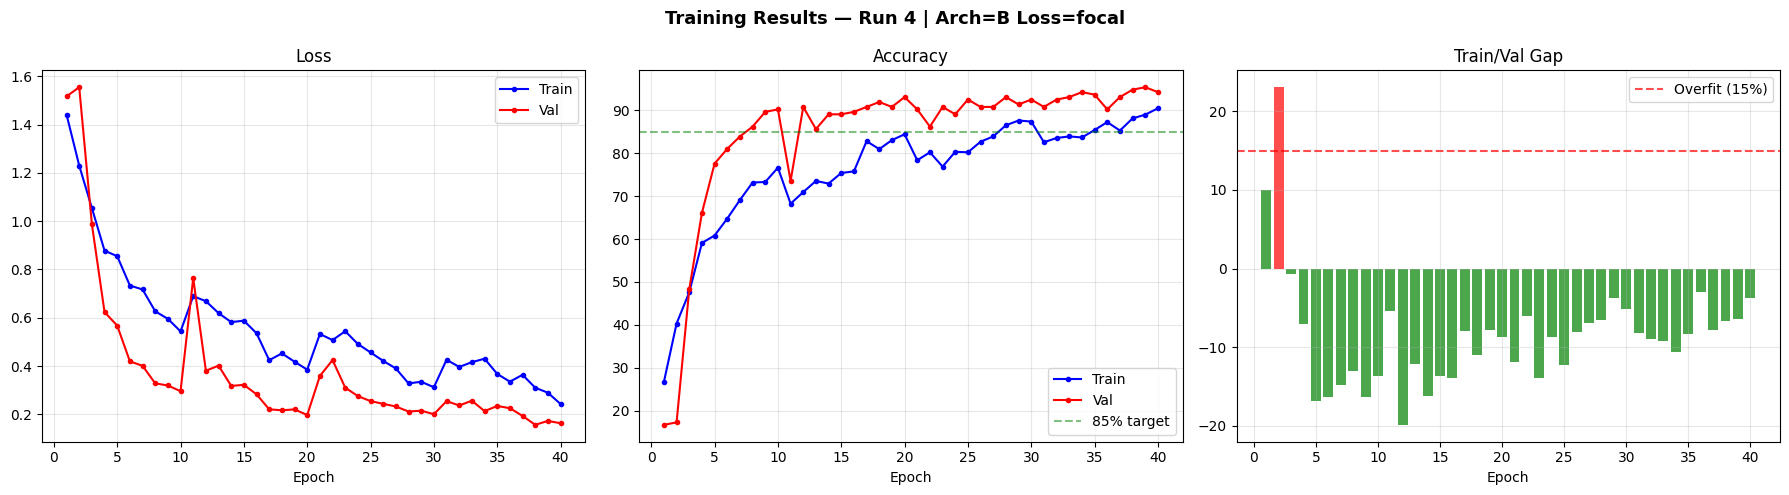

Training curves saved


In [33]:
# ============================================================
# CELL 9 — TRAINING CURVES
# ============================================================

epochs_ran = len(history['train_loss'])
x = range(1, epochs_ran + 1)

fig, axes = plt.subplots(1, 3, figsize=(18, 5))
fig.suptitle(
    f'Training Results — Run {run_id} | '
    f'Arch={ARCH_VARIANT} Loss={LOSS_TYPE}',
    fontsize=13, fontweight='bold'
)

# Loss
axes[0].plot(x, history['train_loss'], 'b-o', ms=3, label='Train')
axes[0].plot(x, history['val_loss'],   'r-o', ms=3, label='Val')
axes[0].set_title('Loss')
axes[0].set_xlabel('Epoch')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

# Accuracy
axes[1].plot(x, history['train_acc'], 'b-o', ms=3, label='Train')
axes[1].plot(x, history['val_acc'],   'r-o', ms=3, label='Val')
axes[1].axhline(y=85, color='g', linestyle='--', alpha=0.5, label='85% target')
axes[1].set_title('Accuracy')
axes[1].set_xlabel('Epoch')
axes[1].legend()
axes[1].grid(True, alpha=0.3)

# Gap
gap    = [t - v for t, v in zip(history['train_acc'], history['val_acc'])]
colors = ['red' if g > 15 else 'green' for g in gap]
axes[2].bar(x, gap, color=colors, alpha=0.7)
axes[2].axhline(y=15, color='red', linestyle='--', alpha=0.7, label='Overfit (15%)')
axes[2].set_title('Train/Val Gap')
axes[2].set_xlabel('Epoch')
axes[2].legend()
axes[2].grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig(os.path.join(RUN_DIR, 'training_curves.png'), dpi=150)
plt.show()
print('Training curves saved')

In [34]:
# ============================================================
# CELL 10 — EVALUATION ON TEST SET
# ============================================================

# Load best model
checkpoint = torch.load(BEST_PATH, map_location=DEVICE)
model.load_state_dict(checkpoint['model_state'])
model.eval()
print(f'Loaded best model from epoch {checkpoint["epoch"]} '
      f'({checkpoint["val_acc"]:.1f}% val acc)')

all_preds, all_labels, all_probs = [], [], []

with torch.no_grad():
    for images, labels in test_loader:
        images  = images.to(DEVICE)
        outputs = model(images)
        probs   = torch.softmax(outputs, dim=1)
        preds   = outputs.argmax(dim=1)
        all_preds.extend(preds.cpu().numpy())
        all_labels.extend(labels.numpy())
        all_probs.extend(probs.cpu().numpy())

all_preds  = np.array(all_preds)
all_labels = np.array(all_labels)
all_probs  = np.array(all_probs)

overall_acc = (all_preds == all_labels).mean() * 100

print(f'\nTEST SET RESULTS')
print('=' * 50)
print(f'Overall Accuracy: {overall_acc:.1f}%')
print()
print('Per-Class Accuracy:')
print('-' * 45)

per_class_acc = {}
for i, cls in enumerate(CLASS_NAMES):
    mask    = all_labels == i
    if mask.sum() == 0:
        continue
    acc     = (all_preds[mask] == all_labels[mask]).mean() * 100
    per_class_acc[cls] = acc
    status  = 'OK' if acc >= 70 else 'BELOW TARGET'
    print(f'  {cls:20} {acc:6.1f}%  {status}')

print()
print('Classification Report:')
print('-' * 45)
print(classification_report(
    all_labels, all_preds,
    target_names=CLASS_NAMES, digits=3
))

# Save metrics
metrics = {
    'overall_acc' : float(overall_acc),
    'per_class'   : {k: float(v) for k, v in per_class_acc.items()}
}
with open(os.path.join(RUN_DIR, 'metrics.json'), 'w') as f:
    json.dump(metrics, f, indent=2)
print('Metrics saved')

Loaded best model from epoch 39 (95.4% val acc)

TEST SET RESULTS
Overall Accuracy: 97.1%

Per-Class Accuracy:
---------------------------------------------
  0_background           93.3%  OK
  1_sodium              100.0%  OK
  2_copper               96.6%  OK
  3_strontium           100.0%  OK
  4_potassium           100.0%  OK
  5_normal               93.3%  OK

Classification Report:
---------------------------------------------
              precision    recall  f1-score   support

0_background      1.000     0.933     0.966        30
    1_sodium      1.000     1.000     1.000        30
    2_copper      0.966     0.966     0.966        29
 3_strontium      0.968     1.000     0.984        30
 4_potassium      1.000     1.000     1.000        25
    5_normal      0.903     0.933     0.918        30

    accuracy                          0.971       174
   macro avg      0.973     0.972     0.972       174
weighted avg      0.972     0.971     0.971       174

Metrics saved


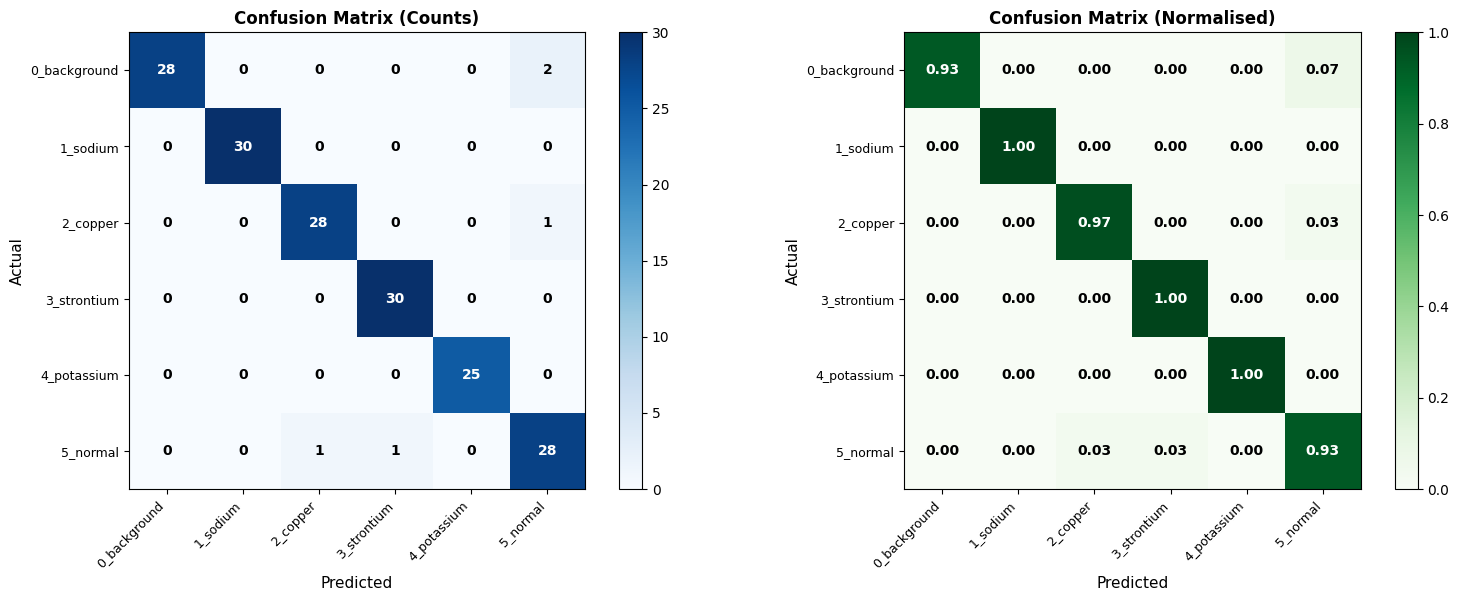


Most Confused Class Pairs:
  No major confusion between classes
Confusion matrix saved


In [35]:
# ============================================================
# CELL 11 — CONFUSION MATRIX (pure matplotlib, no seaborn)
# ============================================================

cm            = confusion_matrix(all_labels, all_preds)
cm_normalized = cm.astype('float') / cm.sum(axis=1)[:, np.newaxis]

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

def plot_cm(ax, data, title, fmt, cmap):
    im = ax.imshow(data, interpolation='nearest', cmap=cmap)
    plt.colorbar(im, ax=ax)
    ax.set_title(title, fontsize=12, fontweight='bold')
    ax.set_xlabel('Predicted', fontsize=11)
    ax.set_ylabel('Actual', fontsize=11)
    ax.set_xticks(range(NUM_CLASSES))
    ax.set_yticks(range(NUM_CLASSES))
    ax.set_xticklabels(CLASS_NAMES, rotation=45, ha='right', fontsize=9)
    ax.set_yticklabels(CLASS_NAMES, fontsize=9)
    thresh = data.max() / 2.0
    for i in range(NUM_CLASSES):
        for j in range(NUM_CLASSES):
            color = 'white' if data[i, j] > thresh else 'black'
            ax.text(j, i, format(data[i, j], fmt),
                    ha='center', va='center',
                    color=color, fontsize=10, fontweight='bold')

plot_cm(axes[0], cm,            'Confusion Matrix (Counts)',     'd',   plt.cm.Blues)
plot_cm(axes[1], cm_normalized, 'Confusion Matrix (Normalised)', '.2f', plt.cm.Greens)

plt.tight_layout()
plt.savefig(os.path.join(RUN_DIR, 'confusion_matrix.png'), dpi=150)
plt.show()

# Print confused pairs
print('\nMost Confused Class Pairs:')
found = False
for i in range(NUM_CLASSES):
    for j in range(NUM_CLASSES):
        if i != j and cm[i][j] > 0:
            pct = cm[i][j] / cm[i].sum() * 100
            if pct > 10:
                print(f'  {CLASS_NAMES[i]:20} -> '
                      f'{CLASS_NAMES[j]:20} {pct:.0f}% of the time')
                found = True
if not found:
    print('  No major confusion between classes')
print('Confusion matrix saved')

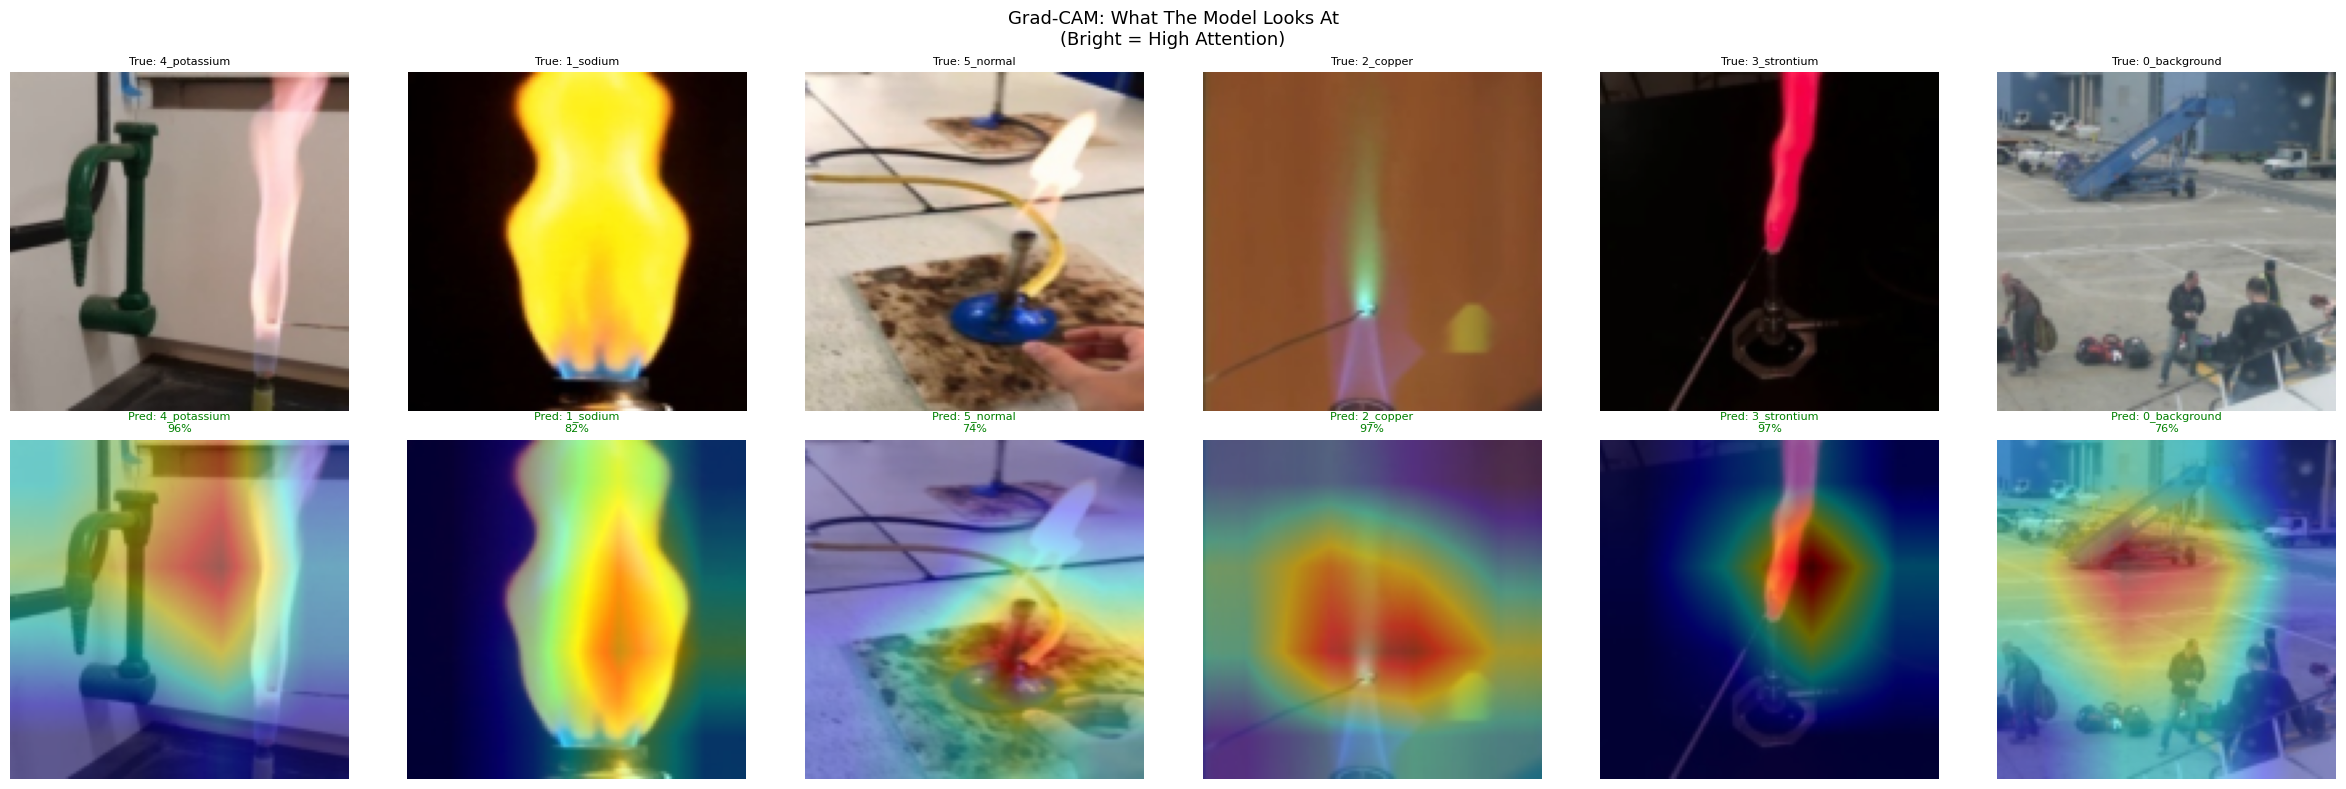

Grad-CAM saved
Check: Is model looking at FLAME or background?


In [36]:
# ============================================================
# CELL 12 — GRAD-CAM VISUALIZATION
# Verifies model looks at flame not background
# ============================================================  
import cv2

def generate_gradcam(model, image_tensor, target_layer, target_class=None):
    model.eval()
    gradients, activations = [], []

    def fwd_hook(module, inp, out):
        activations.append(out.detach())
    def bwd_hook(module, gin, gout):
        gradients.append(gout[0].detach())

    fh = target_layer.register_forward_hook(fwd_hook)
    bh = target_layer.register_full_backward_hook(bwd_hook)

    img    = image_tensor.unsqueeze(0).to(DEVICE)
    output = model(img)

    if target_class is None:
        target_class = output.argmax(dim=1).item()

    model.zero_grad()
    output[0, target_class].backward()

    fh.remove()
    bh.remove()

    grads   = gradients[0].squeeze(0)
    acts    = activations[0].squeeze(0)
    weights = grads.mean(dim=(1, 2))
    cam     = (weights[:, None, None] * acts).sum(0)
    cam     = F.relu(cam)
    cam     = cam - cam.min()
    cam     = cam / (cam.max() + 1e-8)
    cam     = cam.cpu().numpy()

    probs = torch.softmax(output, dim=1)[0]
    return cam, target_class, probs.detach().cpu().numpy()


target_layer = model.head[0]

# Get one sample per class from test set
sample_images, sample_labels = [], []
seen = set()
for img, lbl in test_subset:
    if lbl not in seen:
        sample_images.append(img)
        sample_labels.append(lbl)
        seen.add(lbl)
    if len(seen) == NUM_CLASSES:
        break

fig, axes = plt.subplots(
    2, NUM_CLASSES,
    figsize=(4 * NUM_CLASSES, 8)
)
fig.suptitle(
    'Grad-CAM: What The Model Looks At\n(Bright = High Attention)',
    fontsize=13
)

mean = np.array([0.485, 0.456, 0.406])
std  = np.array([0.229, 0.224, 0.225])

for col, (img_t, true_lbl) in enumerate(
    zip(sample_images, sample_labels)
):
    cam, pred_cls, probs = generate_gradcam(
        model, img_t, target_layer
    )
    img_np = img_t.permute(1, 2, 0).numpy()
    img_np = np.clip(img_np * std + mean, 0, 1)

    cam_r   = cv2.resize(cam, (IMG_SIZE, IMG_SIZE))
    heatmap = cv2.applyColorMap(
        np.uint8(255 * cam_r), cv2.COLORMAP_JET
    )
    heatmap = cv2.cvtColor(heatmap, cv2.COLOR_BGR2RGB) / 255.0
    overlay = np.clip(img_np * 0.6 + heatmap * 0.4, 0, 1)

    axes[0][col].imshow(img_np)
    axes[0][col].set_title(
        f'True: {CLASS_NAMES[true_lbl]}', fontsize=8
    )
    axes[0][col].axis('off')

    conf  = probs[pred_cls] * 100
    color = 'green' if pred_cls == true_lbl else 'red'
    axes[1][col].imshow(overlay)
    axes[1][col].set_title(
        f'Pred: {CLASS_NAMES[pred_cls]}\n{conf:.0f}%',
        fontsize=8, color=color
    )
    axes[1][col].axis('off')

plt.tight_layout()
plt.savefig(
    os.path.join(RUN_DIR, 'gradcam.png'),
    dpi=150, bbox_inches='tight'
)
plt.show()
print('Grad-CAM saved')
print('Check: Is model looking at FLAME or background?')

In [38]:
# ============================================================
# CELL 14 — PREDICT ON NEW IMAGE
# Upload from local machine, TTA averaged, confidence threshold
# Strontium/Potassium confusion warning included
# ============================================================

def predict_with_tta(model, image_path, class_names,
                     conf_threshold=0.70, tta_runs=5):
    model.eval()

    base_transform = transforms.Compose([
        transforms.Resize((IMG_SIZE, IMG_SIZE)),
        transforms.ToTensor(),
        transforms.Normalize(
            mean=[0.485, 0.456, 0.406],
            std=[0.229, 0.224, 0.225]
        )
    ])
    tta_transform = transforms.Compose([
        transforms.Resize((IMG_SIZE, IMG_SIZE)),
        transforms.RandomHorizontalFlip(p=0.5),
        transforms.ColorJitter(brightness=0.1, contrast=0.1),
        transforms.ToTensor(),
        transforms.Normalize(
            mean=[0.485, 0.456, 0.406],
            std=[0.229, 0.224, 0.225]
        )
    ])

    img       = Image.open(image_path).convert('RGB')
    all_probs = []

    with torch.no_grad():
        t = base_transform(img).unsqueeze(0).to(DEVICE)
        all_probs.append(
            torch.softmax(model(t), dim=1).cpu().numpy()
        )
        for _ in range(tta_runs - 1):
            t = tta_transform(img).unsqueeze(0).to(DEVICE)
            all_probs.append(
                torch.softmax(model(t), dim=1).cpu().numpy()
            )

    avg_probs     = np.mean(all_probs, axis=0)[0]
    pred_idx      = int(avg_probs.argmax())
    confidence    = float(avg_probs[pred_idx])
    predicted_cls = class_names[pred_idx]

    # Strontium / Potassium confusion check
    sr_idx = next(
        (i for i, c in enumerate(class_names) if 'strontium' in c), None
    )
    k_idx  = next(
        (i for i, c in enumerate(class_names) if 'potassium' in c), None
    )
    confused_pair = False
    if sr_idx is not None and k_idx is not None:
        sr_p     = float(avg_probs[sr_idx])
        k_p      = float(avg_probs[k_idx])
        combined = sr_p + k_p
        diff     = abs(sr_p - k_p)
        if combined > 0.40 and diff < 0.25:
            confused_pair = True

    # Plot
    fig, axes = plt.subplots(1, 2, figsize=(14, 6))
    axes[0].imshow(img)
    axes[0].axis('off')

    if confused_pair:
        title_color = 'orange'
        title_text  = (
            f'UNCERTAIN\n'
            f'Strontium ({avg_probs[sr_idx]*100:.1f}%) vs '
            f'Potassium ({avg_probs[k_idx]*100:.1f}%) unclear\n'
            f'Retake in better lighting'
        )
    elif confidence >= conf_threshold:
        title_color = 'green'
        title_text  = (
            f'Predicted: {predicted_cls}\n'
            f'Confidence: {confidence*100:.1f}%'
        )
    else:
        title_color = 'red'
        title_text  = (
            f'UNCERTAIN\n'
            f'Confidence {confidence*100:.1f}% '
            f'< {conf_threshold*100:.0f}% threshold\n'
            f'Retake in better lighting'
        )

    axes[0].set_title(
        title_text, fontsize=11,
        color=title_color, fontweight='bold'
    )

    bar_colors = []
    for i in range(len(class_names)):
        if confused_pair and i in [sr_idx, k_idx]:
            bar_colors.append('orange')
        elif i == pred_idx:
            bar_colors.append('green')
        else:
            bar_colors.append('steelblue')

    bars = axes[1].barh(
        class_names, avg_probs * 100, color=bar_colors
    )
    axes[1].axvline(
        x=conf_threshold * 100,
        color='red', linestyle='--',
        label=f'{conf_threshold*100:.0f}% threshold'
    )
    axes[1].set_xlabel('Confidence (%)')
    axes[1].set_title('Class Probabilities (TTA averaged)')
    axes[1].legend()

    for bar, prob in zip(bars, avg_probs):
        axes[1].text(
            bar.get_width() + 0.5,
            bar.get_y() + bar.get_height() / 2,
            f'{prob*100:.1f}%', va='center', fontsize=9
        )

    plt.tight_layout()
    plt.show()

    print('\n' + '=' * 50)
    if confused_pair:
        print(f'UNCERTAIN: Strontium/Potassium too close')
        print(f'  Strontium : {avg_probs[sr_idx]*100:.1f}%')
        print(f'  Potassium : {avg_probs[k_idx]*100:.1f}%')
    elif confidence >= conf_threshold:
        print(f'Chemical : {predicted_cls}')
        print(f'Confidence: {confidence*100:.1f}%')
        print(f'TTA runs  : {tta_runs}')
    else:
        print(f'UNCERTAIN — below {conf_threshold*100:.0f}% threshold')
        print(f'Best guess: {predicted_cls} ({confidence*100:.1f}%)')
    print('=' * 50)

    return predicted_cls, confidence


# ── Kaggle file upload widget ─────────────────────────────
import ipywidgets as widgets
from IPython.display import display

upload_widget = widgets.FileUpload(
    accept='.jpg,.jpeg,.png,.webp',
    multiple=False
)
output_zone = widgets.Output()

print('Upload an image to test the model:')

def on_upload(change):
    with output_zone:
        output_zone.clear_output()
        if not upload_widget.value:
            print('No file uploaded.')
            return

        # ipywidgets v8 format
        uploaded_file = upload_widget.value[0]
        file_name     = uploaded_file['name']
        file_content  = uploaded_file['content']

        print(f'Processing: {file_name}')

        temp_path = os.path.join('/kaggle/working', file_name)
        with open(temp_path, 'wb') as f:
            f.write(bytes(file_content))

        try:
            pred_class, conf = predict_with_tta(
                model,
                temp_path,
                CLASS_NAMES,          # fixed: was class_folders
                conf_threshold=CONF_THRESHOLD
            )
        except Exception as e:
            print(f'Error during prediction: {str(e)}')
            import traceback
            traceback.print_exc()
        finally:
            if os.path.exists(temp_path):
                os.remove(temp_path)

upload_widget.observe(on_upload, names='value')
display(upload_widget)
display(output_zone)

Upload an image to test the model:


FileUpload(value=(), accept='.jpg,.jpeg,.png,.webp', description='Upload')

Output()